<a href="https://www.kaggle.com/code/atrbyg24/calorie-expenditure?scriptVersionId=237443802" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [75]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import shap
import optuna

import warnings
warnings.simplefilter("ignore")

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv',index_col = 'id')
test = pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv',index_col = 'id')

In [3]:
train.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
id,,,,,,,,
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  object 
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 51.5+ MB


In [5]:
train.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
train['Sex'].value_counts()

Sex
female    375721
male      374279
Name: count, dtype: int64

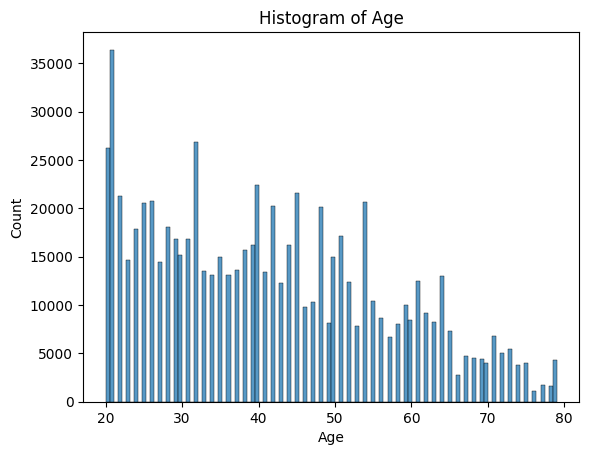

<Figure size 640x480 with 0 Axes>

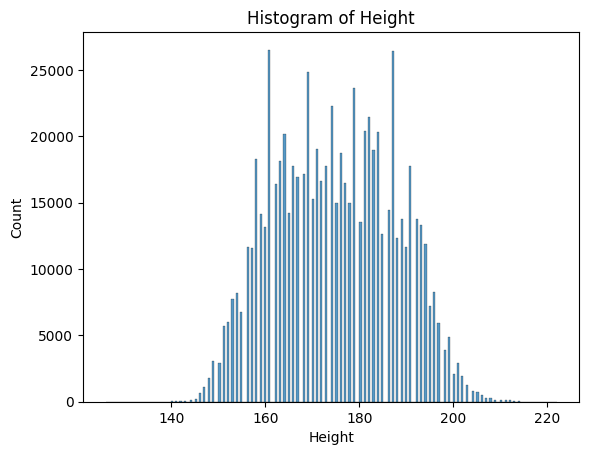

<Figure size 640x480 with 0 Axes>

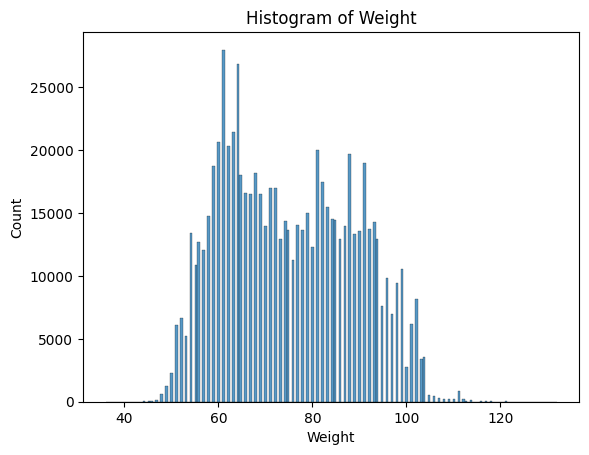

<Figure size 640x480 with 0 Axes>

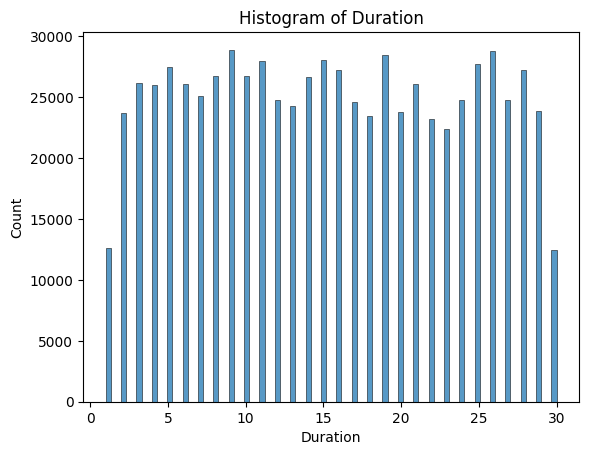

<Figure size 640x480 with 0 Axes>

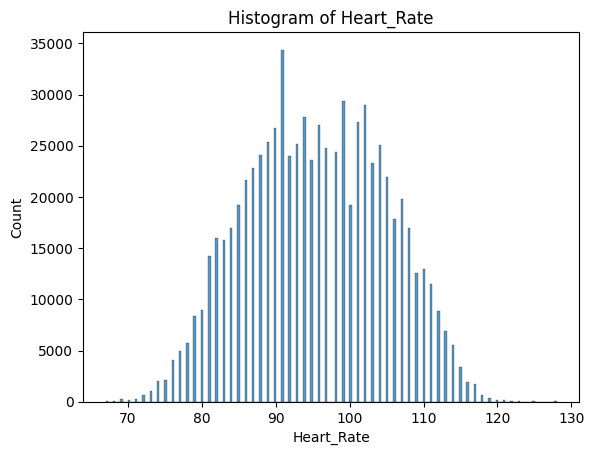

<Figure size 640x480 with 0 Axes>

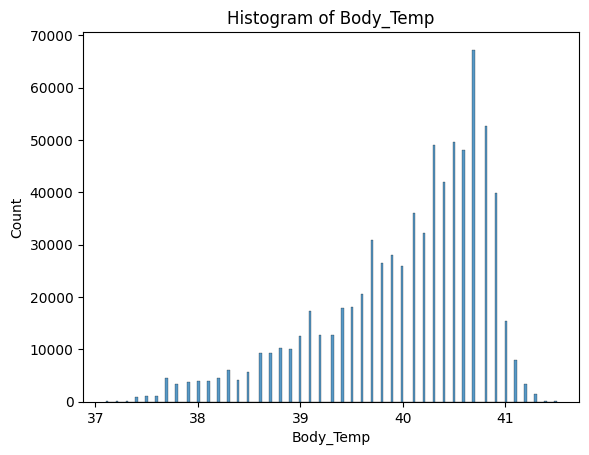

<Figure size 640x480 with 0 Axes>

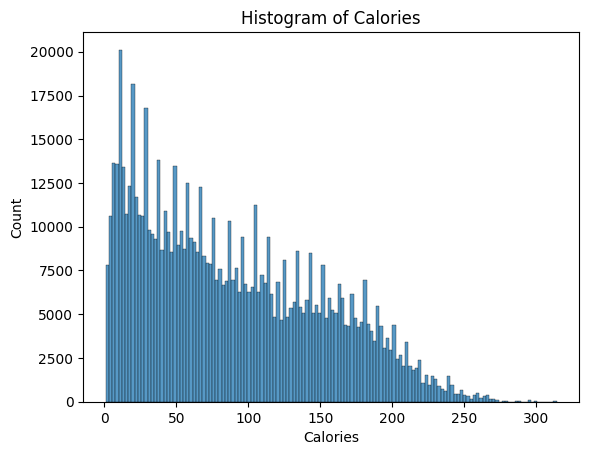

<Figure size 640x480 with 0 Axes>

In [7]:
num_cols = ['Age','Height','Weight','Duration','Heart_Rate','Body_Temp','Calories']
for col in num_cols:
    plt.figure()
    sns.histplot(data = train[num_cols], x = col)
    plt.title(f"Histogram of {col}")
    plt.show()
    plt.clf()

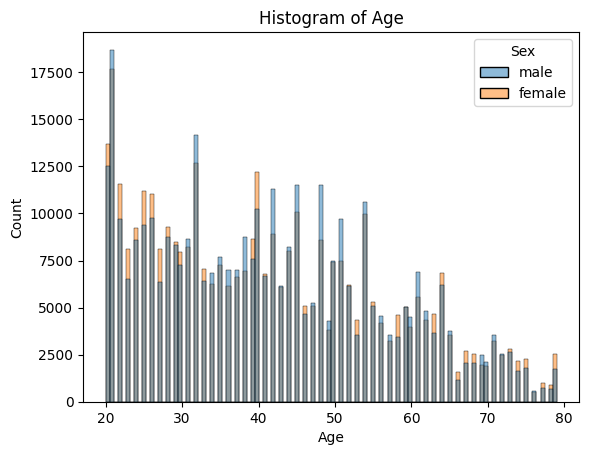

<Figure size 640x480 with 0 Axes>

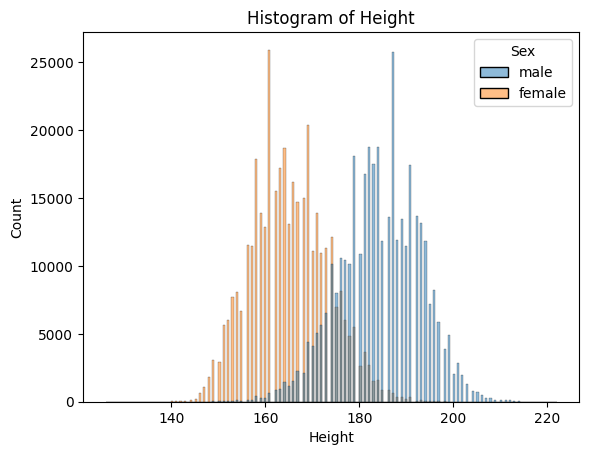

<Figure size 640x480 with 0 Axes>

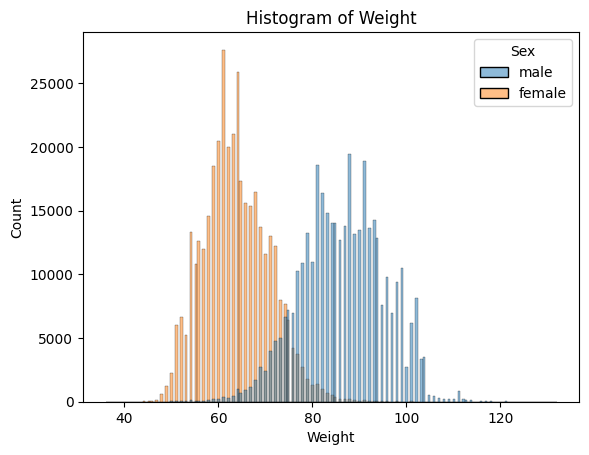

<Figure size 640x480 with 0 Axes>

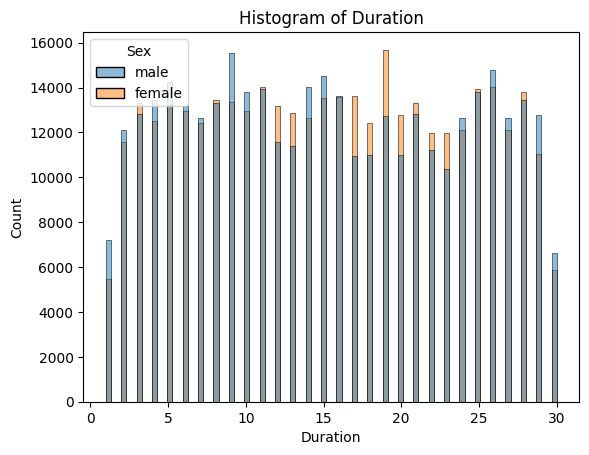

<Figure size 640x480 with 0 Axes>

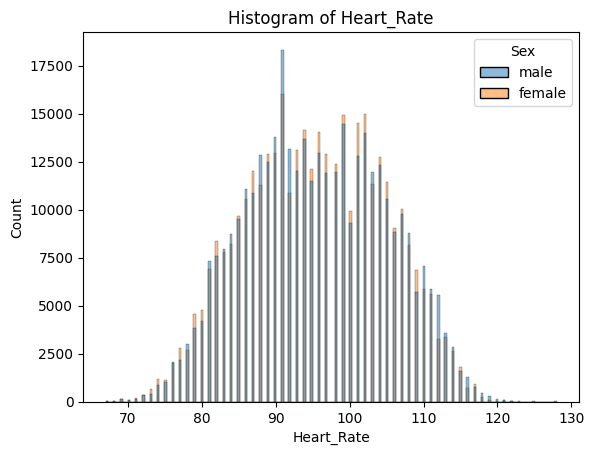

<Figure size 640x480 with 0 Axes>

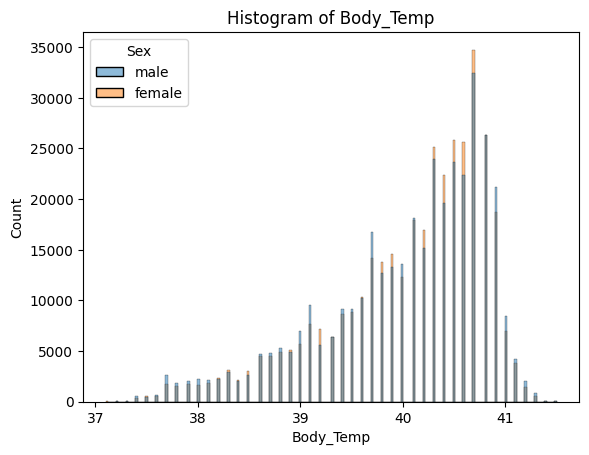

<Figure size 640x480 with 0 Axes>

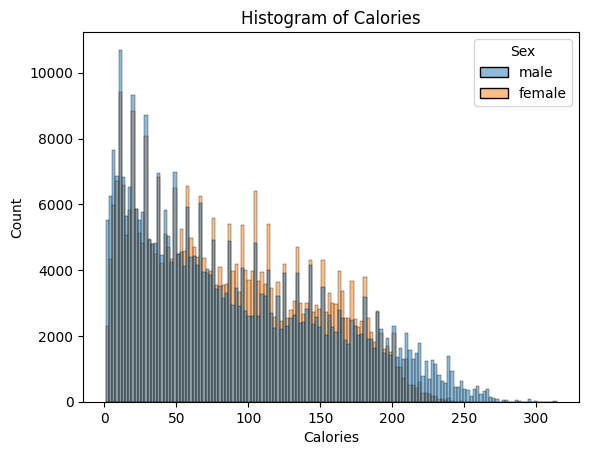

<Figure size 640x480 with 0 Axes>

In [8]:
for col in num_cols:
    plt.figure()
    sns.histplot(data = train, x = col,hue='Sex')
    plt.title(f"Histogram of {col}")
    plt.show()
    plt.clf()

<Axes: >

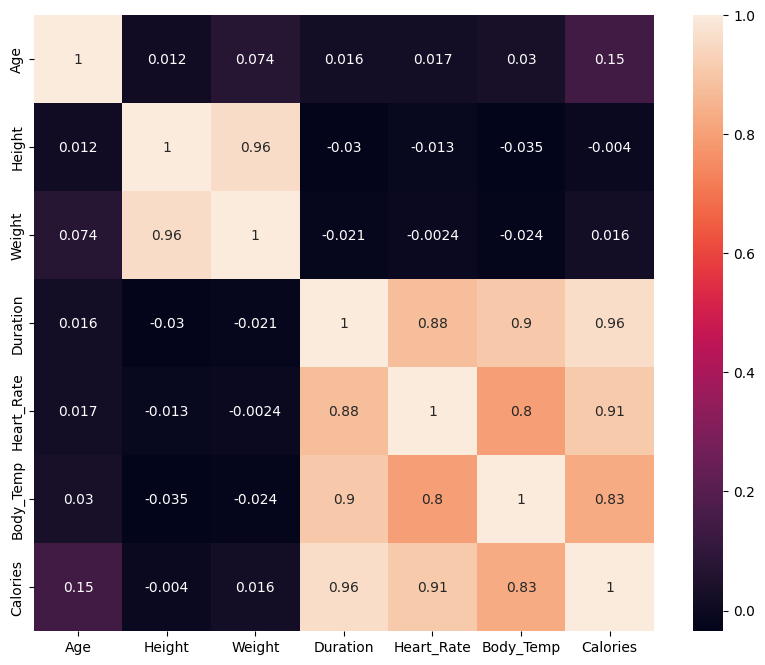

In [10]:
corr = train[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr,annot=True)

In [11]:
y_train = np.log1p(train['Calories'])
X_train = train.drop('Calories',axis=1)

In [52]:
def bmi_feature(X):
    return X[:,[0]] / ((X[:,[1]] / 100) ** 2)

def bmi_name(function_transformer,feature_names_in):
    return ['BMI']

def bmi_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(bmi_feature,feature_names_out=bmi_name),
        StandardScaler()
    )

def interaction_features(X):
    return X[:,[0]] * X[:,[1]]

def interaction_name(function_transformer,feature_names_in):
    return ['interaction']

def interaction_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(interaction_features,feature_names_out=interaction_name),
        StandardScaler()
    )

bmi_transformer = FunctionTransformer(bmi_feature,feature_names_out=bmi_name)

cat_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"),
)

num_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

preprocessor = ColumnTransformer(
    transformers=[
        ('bmi', bmi_pipeline(), ['Weight','Height']),
        ('age_height',interaction_pipeline(),['Age','Height']),
        ('age_weight',interaction_pipeline(),['Age','Weight']),
        ('age_duration',interaction_pipeline(),['Age','Duration']),
        ('age_heart_rate',interaction_pipeline(),['Age','Heart_Rate']),
        ('age_body_temp',interaction_pipeline(),['Age','Body_Temp']),
        ('height_weight',interaction_pipeline(),['Height','Weight']),
        ('height_duration',interaction_pipeline(),['Height','Duration']),
        ('height_heart_rate',interaction_pipeline(),['Height','Heart_Rate']),
        ('height_body_temp',interaction_pipeline(),['Height','Body_Temp']),
        ('weight_duration',interaction_pipeline(),['Weight','Duration']),
        ('weight_heart_rate',interaction_pipeline(),['Weight','Heart_Rate']),
        ('weight_body_temp',interaction_pipeline(),['Weight','Body_Temp']),
        ('duration_heart_rate',interaction_pipeline(),['Duration','Heart_Rate']),
        ('duration_body_temp',interaction_pipeline(),['Duration','Body_Temp']),
        ('heart_rate_body_temp',interaction_pipeline(),['Heart_Rate','Body_Temp']),
        ('num', num_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', cat_transformer, make_column_selector(dtype_include=object)),
    ],remainder= 'passthrough')


In [63]:
xgb_reg = Pipeline([
    ('preprocess',preprocessor),
    ('xgb',XGBRegressor(random_state=42))
])
xgb_reg.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('bmi',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function bmi_name at 0x78cfd02c9260>,
                                                                                       func=<function bmi_feature at 0x78cfea5254e0>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Weight', '...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [58]:
xgb_rmses = -cross_val_score(xgb_reg,X_train,y_train,scoring="neg_root_mean_squared_error",cv=5)
pd.Series(xgb_rmses).describe()

count    5.000000
mean     0.062516
std      0.001231
min      0.061177
25%      0.061689
50%      0.062237
75%      0.063232
max      0.064246
dtype: float64

In [66]:
xgb_model = xgb_reg.named_steps['xgb']

In [69]:
xgb_importances = xgb_model.feature_importances_
sorted(zip(xgb_importances, xgb_reg.named_steps['preprocess'].get_feature_names_out()),reverse=True)

[(0.9115207, 'duration_heart_rate__interaction'),
 (0.03044536, 'num__Duration'),
 (0.014928505, 'heart_rate_body_temp__interaction'),
 (0.011873545, 'age_heart_rate__interaction'),
 (0.011541093, 'cat__Sex_female'),
 (0.006545084, 'age_duration__interaction'),
 (0.0041667027, 'age_weight__interaction'),
 (0.0022012456, 'num__Weight'),
 (0.0016634959, 'num__Heart_Rate'),
 (0.0014066122, 'weight_heart_rate__interaction'),
 (0.00065118354, 'height_heart_rate__interaction'),
 (0.0005130901, 'num__Body_Temp'),
 (0.00042043655, 'weight_body_temp__interaction'),
 (0.00041464405, 'height_weight__interaction'),
 (0.0003615952, 'age_body_temp__interaction'),
 (0.0002917051, 'height_duration__interaction'),
 (0.00027276724, 'num__Age'),
 (0.0001910177, 'weight_duration__interaction'),
 (0.00015129185, 'duration_body_temp__interaction'),
 (0.00012901744, 'num__Height'),
 (0.00012316139, 'height_body_temp__interaction'),
 (0.00011480078, 'age_height__interaction'),
 (7.292842e-05, 'bmi__BMI'),
 (0

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 350, 550)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.03, log=True) 
    max_depth = trial.suggest_int('max_depth', 5, 8)
    subsample = trial.suggest_float('subsample', 0.7, 0.8) 
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.9, 1.0)

    xgb = XGBRegressor(n_estimators=n_estimators,
                       learning_rate=learning_rate,
                       max_depth=max_depth,
                       subsample=subsample,
                       colsample_bytree=colsample_bytree,
                       random_state=42)

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('xgb', xgb)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='neg_mean_squared_error')
    return scores.mean()

study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=10) 

print("Best trial:", study.best_trial)
best_xgb_reg_optuna = Pipeline([
    ('preprocess', preprocessor),
    ('xgb', XGBRegressor(**study.best_params, random_state=42))
])
best_xgb_reg_optuna.fit(X_train, y_train)

[I 2025-05-02 19:39:09,702] A new study created in memory with name: no-name-b82e5c14-f4fc-4a15-9fdb-4889d1700671
[I 2025-05-02 19:40:35,401] Trial 0 finished with value: -0.0036848506842588045 and parameters: {'n_estimators': 421, 'learning_rate': 0.016816301575567464, 'max_depth': 7, 'subsample': 0.7974803276910327, 'colsample_bytree': 0.9413439185148614}. Best is trial 0 with value: -0.0036848506842588045.


In [77]:
sample = pd.read_csv('/kaggle/input/playground-series-s5e5/sample_submission.csv',index_col='id')

In [78]:
sample['Calories'] = np.expm1(best_xgb_reg_optuna.predict(test))

In [79]:
sample.to_csv('submission.csv')